# 1. LOAD AND INSPECT DATA

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


REPO_ROOT = Path.cwd().parent.parent.parent
print(f"Repository root: {REPO_ROOT}")

ELECTION_DIR = REPO_ROOT / "processed-data" / "elections"
DEMOGRAPHICS_DIR = REPO_ROOT / "processed-data" / "demographics"
SWING_DIR = REPO_ROOT / "processed-data" / "features" / "swing_states" / "margin"

YEARS = [2009, 2013, 2017, 2021]

# Load election data
election_dfs = []
for year in YEARS:
    filepath = ELECTION_DIR / f"relative_{year}.csv"
    
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath)
    df['year'] = year
    election_dfs.append(df)

if not election_dfs:
    raise FileNotFoundError("No election data files found! Check your paths.")

election_df = pd.concat(election_dfs, ignore_index=True)

print(f"Shape: {election_df.shape}")
print(f"Years covered: {election_df['year'].unique()}")
print(f"Unique polling areas (Gruppe): {election_df['Gruppe'].nunique()}")
print(f"\nColumns ({len(election_df.columns)}): {election_df.columns.tolist()[:10]}...")


Repository root: c:\Users\GryLipczak\OneDrive - Lipczak\Skrivebord\Software Design\3 sem\Data Mining\Assignment 2\Git repo\local-elections-damin2025
Shape: (232, 48)
Years covered: [2009 2013 2017 2021]
Unique polling areas (Gruppe): 58

Columns (48): ['Gruppe', 'PollingAreaID', 'Name', 'DistrictNo', 'District', 'Municipality', 'Eligible voters', 'Voter turnout', 'Blank votes', 'Other invalid votes']...


# 2. CHECK FOR MISSING VALUES

In [ ]:
print("\n" + "=" * 60)
print("MISSING VALUES CHECK - ELECTION DATA")
print("=" * 60)

# Calculate missing values once
missing_counts = election_df.isnull().sum()
missing_pcts = (missing_counts / len(election_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pcts.values
})

# Filter to IMPORTANT columns only (exclude party columns which can be NaN)
party_cols = [col for col in election_df.columns if len(col) <= 2 and col not in ['year', 'Gruppe']]
important_cols = [col for col in election_df.columns if col not in party_cols]

important_missing = missing_summary[missing_summary['Column'].isin(important_cols)]
important_missing = important_missing[important_missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(important_missing) > 0:
    print("Missing values in important columns:")
    print(important_missing.to_string(index=False))
else:
    print("No missing values in important columns")

# Show party column summary
party_missing = missing_summary[missing_summary['Column'].isin(party_cols)]
party_missing = party_missing[party_missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(party_missing) > 0:
    print(f"\n Party columns with NaN:")
    print(f"   {len(party_missing)} parties have some NaN values")
else:
    print("\n All parties have complete data across all elections")

# Load demographics
demo_df = pd.read_csv(DEMOGRAPHICS_DIR / f"relative_2021.csv")

print("\n" + "=" * 60)
print("MISSING VALUES CHECK - DEMOGRAPHICS (2021)")
print("=" * 60)
print(f"Shape: {demo_df.shape}")

# Calculate missing values once
demo_missing_counts = demo_df.isnull().sum()
demo_missing_pcts = (demo_missing_counts / len(demo_df) * 100).round(2)

demo_missing = pd.DataFrame({
    'Column': demo_missing_counts.index,
    'Missing_Count': demo_missing_counts.values,
    'Missing_Pct': demo_missing_pcts.values
})
demo_missing = demo_missing[demo_missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(demo_missing) > 0:
    print(f"\nColumns with missing values: {len(demo_missing)}")
    print(demo_missing.head(20).to_string(index=False))
else:
    print("✓ No missing values in demographic data!")


MISSING VALUES CHECK - ELECTION DATA
✓ No missing values in important columns (Gruppe, year, metadata)!

📊 Party columns with NaN (expected - parties don't run everywhere):
   10 parties have some NaN values
   This is NORMAL - it means these parties didn't run in all elections/areas

MISSING VALUES CHECK - DEMOGRAPHICS (2021)
Shape: (58, 90)
✓ No missing values in demographic data!


# 3. DISTRIBUTION OF PARTY VOTES

Party columns found: ['A', 'B', 'C', 'D', 'F', 'I', 'J', 'G', 'K', 'N', 'H', 'M', 'U', 'Y', 'O', 'Z', 'L', 'Q', 'R', 'V', 'P', 'E', 'Ø', 'Å', 'T', 'Æ']

Party A:
  Mean: 25.25%
  Median: 25.95%
  Std: 6.87%
  Min: 10.81%, Max: 52.38%

Party V:
  Mean: 8.51%
  Median: 7.90%
  Std: 3.36%
  Min: 1.95%, Max: 23.85%

Party C:
  Mean: 11.17%
  Median: 7.03%
  Std: 10.86%
  Min: 1.20%, Max: 43.65%

Party F:
  Mean: 12.36%
  Median: 10.23%
  Std: 5.88%
  Min: 3.54%, Max: 28.84%

Party Ø:
  Mean: 17.62%
  Median: 16.73%
  Std: 7.30%
  Min: 5.00%, Max: 37.48%

Party B:
  Mean: 9.70%
  Median: 9.67%
  Std: 2.54%
  Min: 3.10%, Max: 15.69%


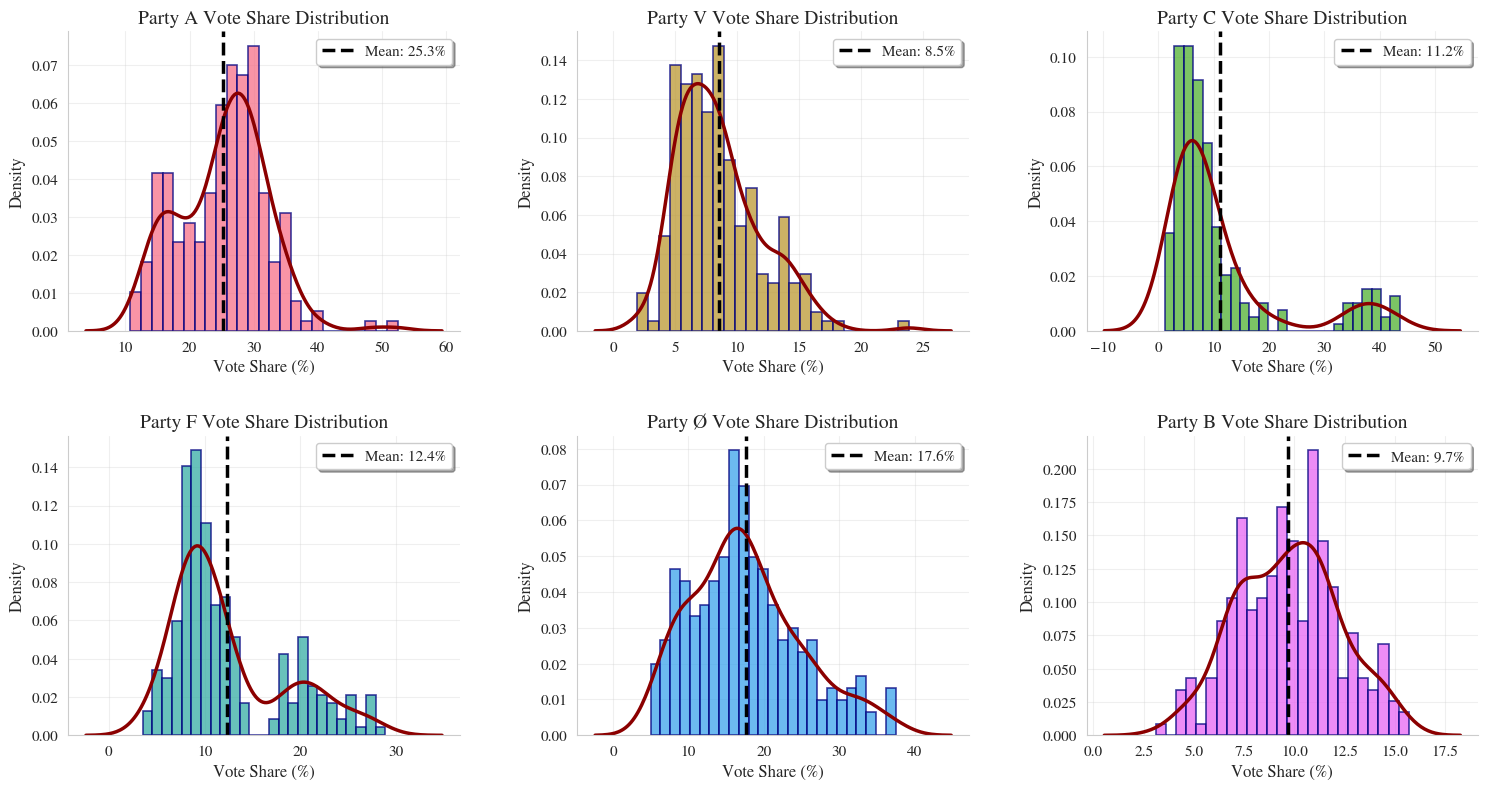

In [45]:
# Get party columns
party_cols = [col for col in election_df.columns if len(col) == 1 and col.isalpha()]
print(f"Party columns found: {party_cols}")

# Calculate summary stats for major parties
major_parties = ['A', 'V', 'C', 'F', 'Ø', 'B']
for party in major_parties:
    if party in election_df.columns:
        stats = election_df[party].describe()
        print(f"\nParty {party}:")
        print(f"  Mean: {stats['mean']:.2f}%")
        print(f"  Median: {stats['50%']:.2f}%")
        print(f"  Std: {stats['std']:.2f}%")
        print(f"  Min: {stats['min']:.2f}%, Max: {stats['max']:.2f}%")

# Visualize distributions 
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=100)
axes = axes.flatten()

colors = sns.color_palette("husl", 6)

for idx, party in enumerate(major_parties):
    if party in election_df.columns:
        data = election_df[party].dropna()
        
        # Histogram + KDE line (original style)
        axes[idx].hist(data, bins=25, color=colors[idx], edgecolor='navy', 
                       linewidth=1.2, alpha=0.75, density=True)
        sns.kdeplot(data, ax=axes[idx], color='darkred', linewidth=2.5)
        
        # Mean line
        mean_val = data.mean()
        axes[idx].axvline(mean_val, color='black', linestyle='--', linewidth=2.5, 
                         label=f'Mean: {mean_val:.1f}%')
        
        axes[idx].set_title(f'Party {party} Vote Share Distribution')
        axes[idx].set_xlabel('Vote Share (%)')
        axes[idx].set_ylabel('Density')
        axes[idx].legend(frameon=True, fancybox=True, shadow=True)

# Remove unused axes completely
available_parties = [p for p in major_parties if p in election_df.columns]
for idx in range(len(available_parties), 6):
    fig.delaxes(axes[idx])

# Zero whitespace layout
plt.tight_layout(pad=0.5)
fig.subplots_adjust(left=0.04, right=0.98, top=0.94, bottom=0.06, wspace=0.3, hspace=0.35)
plt.savefig('eda_party_distributions.png', dpi=300, bbox_inches='tight', pad_inches=0.0, facecolor='white')
plt.show()

# 4. TEMPORAL PATTERNS


Average vote shares by year:
          A      V      C      F      Ø      B
year                                          
2009  29.28   8.76  10.94  21.53  10.17   7.89
2013  27.03  10.72   8.64   9.67  18.51  10.73
2017  26.73   7.45   9.22   7.87  17.84   8.75
2021  17.97   7.12  15.86  10.38  23.95  11.42


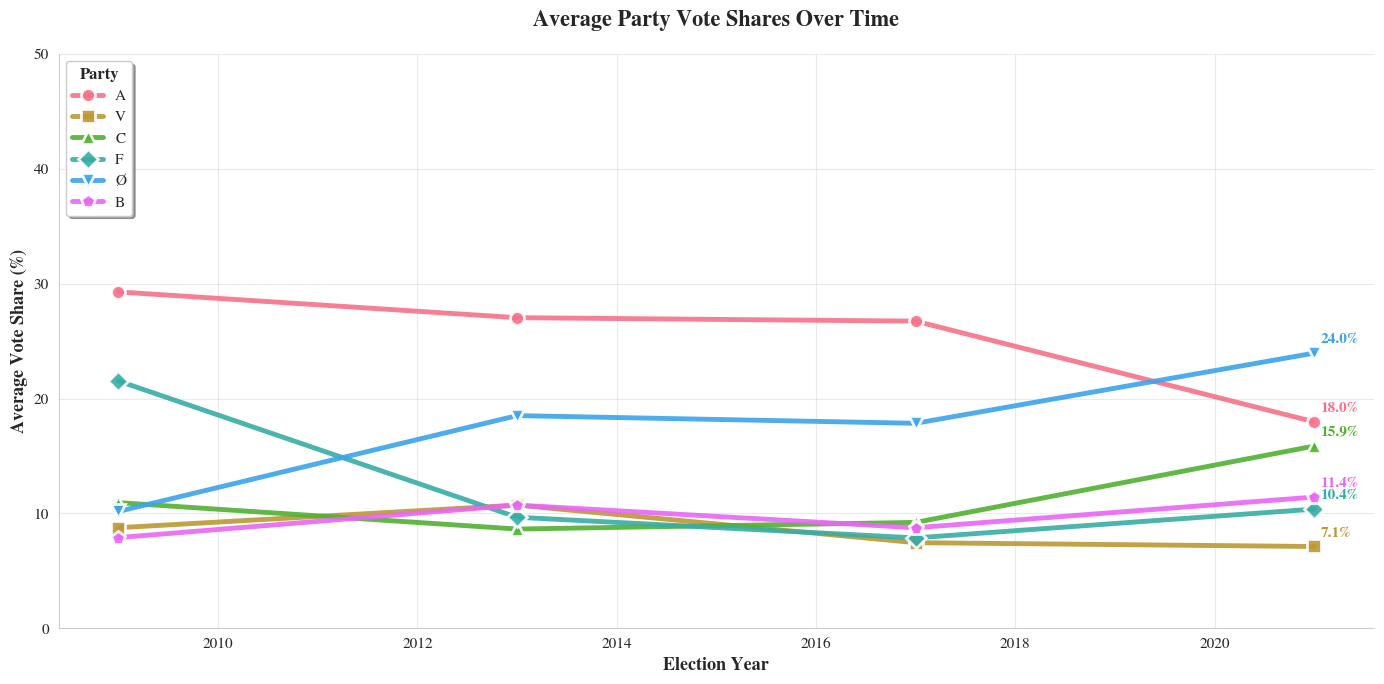

In [46]:
# Vote share changes over time
party_by_year = election_df.groupby('year')[major_parties].mean()
print("\nAverage vote shares by year:")
print(party_by_year.round(2))

# Create improved line plot
fig, ax = plt.subplots(figsize=(14, 7), dpi=100)

# Plot each party with enhanced styling
colors = sns.color_palette("husl", len(major_parties))
markers = ['o', 's', '^', 'D', 'v', 'p']  # Varied markers

for i, party in enumerate(major_parties):
    ax.plot(party_by_year.index, party_by_year[party],  # Already in %
            marker=markers[i % len(markers)], 
            linewidth=3.5, markersize=10, markeredgewidth=2,
            markeredgecolor='white',
            color=colors[i], 
            label=f'{party}',
            alpha=0.9)

# Enhanced styling
ax.set_title('Average Party Vote Shares Over Time', fontweight='bold', pad=20, fontsize=16)
ax.set_xlabel('Election Year', fontweight='bold', fontsize=13)
ax.set_ylabel('Average Vote Share (%)', fontweight='bold', fontsize=13)

# Improve legend
legend = ax.legend(title='Party', title_fontsize=12, fontsize=11, 
                   loc='upper left', frameon=True, fancybox=True, shadow=True,
                   ncol=1, columnspacing=1.0)
legend.get_title().set_fontweight('bold')

# Add value labels on last points
for i, party in enumerate(major_parties):
    last_val = party_by_year[party].iloc[-1]
    ax.annotate(f'{last_val:.1f}%', 
                xy=(party_by_year.index[-1], last_val),
                xytext=(5, 5), textcoords='offset points',
                fontsize=11, fontweight='bold',
                color=colors[i],
                ha='left', va='bottom')

# Grid and limits
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.8)
ax.set_ylim(0, max(party_by_year.values.max() * 1.1, 50))  # Nice upper limit

plt.tight_layout()
plt.savefig('eda_temporal_trends.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 5. SWING STATE FEATURES ANALYSIS


Temporal features shape: (58, 12)
Swing states: 35
Non-swing states: 23


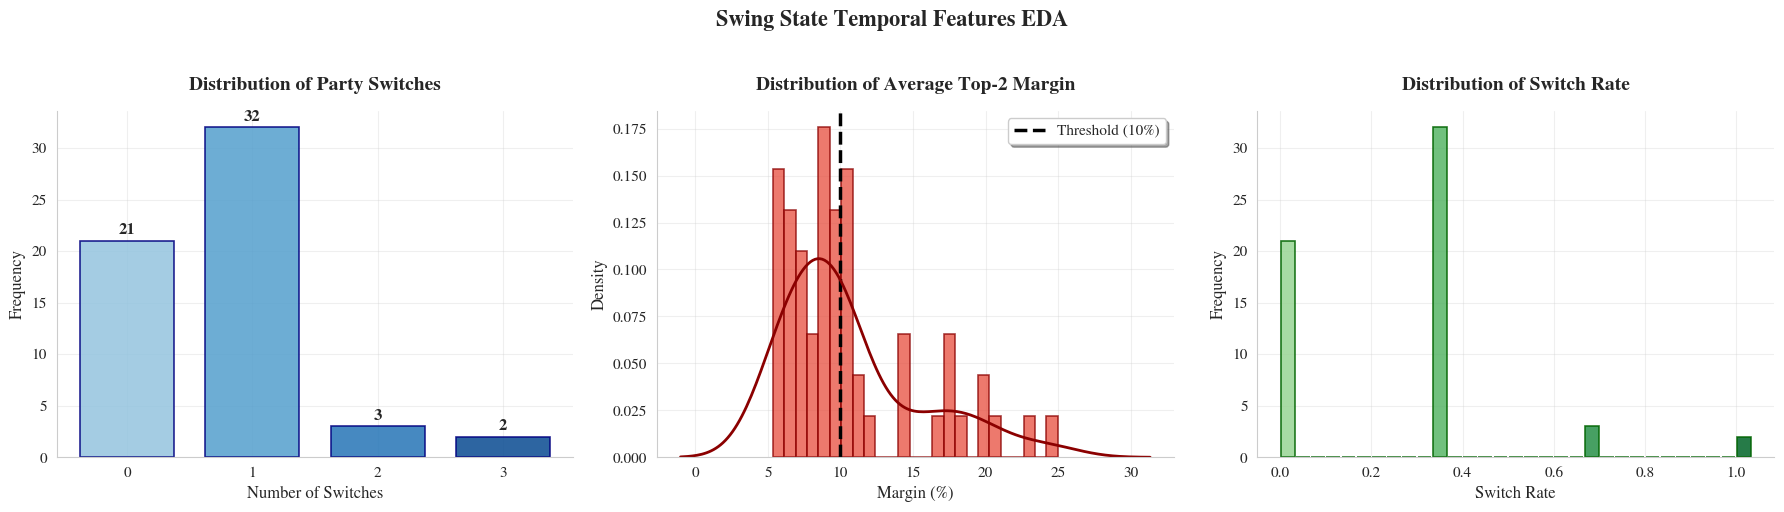

In [38]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"], 
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "-",
    "axes.spines.right": False,
    "axes.spines.top": False
})
sns.set_palette("husl")  # Better color palette

# Load swing features
temporal_features = pd.read_csv(SWING_DIR / "temporal_features.csv")
print(f"\nTemporal features shape: {temporal_features.shape}")
print(f"Swing states: {temporal_features['swing_state'].sum()}")
print(f"Non-swing states: {(1 - temporal_features['swing_state']).sum()}")

# Create improved figure with better layout and colors
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# 1. Party switches - improved bar plot
switch_counts = temporal_features['party_switches'].value_counts().sort_index()
colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(switch_counts)))
axes[0].bar(switch_counts.index, switch_counts.values, 
            color=colors1, edgecolor='navy', linewidth=1.2, alpha=0.85, width=0.75)
axes[0].set_title('Distribution of Party Switches', fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Switches')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(int(temporal_features['party_switches'].max()) + 1))
for i, v in enumerate(switch_counts.values):
    axes[0].text(i, v + max(switch_counts.values)*0.01, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Average margin - improved histogram with KDE overlay
axes[1].hist(temporal_features['avg_top2_margin'], bins=25, color='#e74c3c', edgecolor='darkred', 
             linewidth=1.2, alpha=0.75, density=True)
axes[1].axvline(10, color='black', linestyle='--', linewidth=2.5, label='Threshold (10%)')
kde = sns.kdeplot(temporal_features['avg_top2_margin'], ax=axes[1], color='darkred', linewidth=2)
axes[1].set_title('Distribution of Average Top-2 Margin', fontweight='bold', pad=15)
axes[1].set_xlabel('Margin (%)')
axes[1].set_ylabel('Density')
axes[1].legend(frameon=True, fancybox=True, shadow=True)

# 3. Switch rate - improved bar plot with better scaling
switch_rate_counts = temporal_features['switch_rate'].value_counts().sort_index()
if len(switch_rate_counts) > 0:
    max_rate = switch_rate_counts.index.max()
    bin_width = max(0.005, max_rate / 30)  # Adaptive width for better visuals
    bins = np.arange(0, max_rate + bin_width, bin_width)
    hist, edges = np.histogram(temporal_features['switch_rate'], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    colors3 = plt.cm.Greens(np.linspace(0.4, 0.9, len(centers)))
    axes[2].bar(centers, hist, width=bin_width*0.9, color=colors3, 
                edgecolor='darkgreen', linewidth=1.2, alpha=0.85)
axes[2].set_title('Distribution of Switch Rate', fontweight='bold', pad=15)
axes[2].set_xlabel('Switch Rate')
axes[2].set_ylabel('Frequency')
axes[2].ticklabel_format(axis='y', style='plain')

# Overall styling and save
fig.suptitle('Swing State Temporal Features EDA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_swing_features.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 6. CORRELATION BETWEEN SWING METRICS

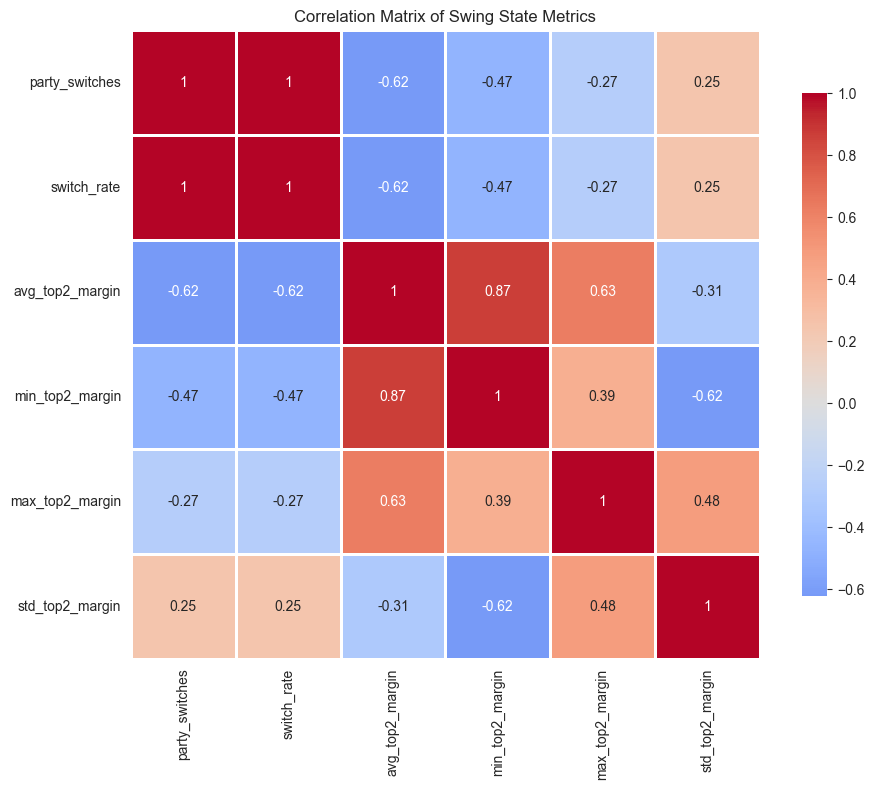

In [33]:
swing_metrics = ['party_switches', 'switch_rate', 'avg_top2_margin', 
                 'min_top2_margin', 'max_top2_margin', 'std_top2_margin']
correlation_matrix = temporal_features[swing_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Swing State Metrics')
plt.tight_layout()
plt.savefig('eda_swing_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. PARTY PARTICIPATION ANALYSIS

In [30]:
# Get party columns
party_cols = [col for col in election_df.columns if len(col) <= 2 and col not in ['year', 'Gruppe']]

# Calculate missing values for each party
party_missing_counts = election_df[party_cols].isnull().sum()
party_missing_pcts = (party_missing_counts / len(election_df) * 100).round(1)

party_participation = pd.DataFrame({
    'Party': party_missing_counts.index,
    'Elections_Missing': party_missing_counts.values,
    'Pct_Missing': party_missing_pcts.values,
    'Elections_Present': len(election_df) - party_missing_counts.values
}).sort_values('Elections_Missing', ascending=False)

# Show which parties ran in ALL elections
always_present = party_participation[party_participation['Elections_Missing'] == 0]
if len(always_present) > 0:
    print(f"\n✓ Parties that ran in ALL {len(election_df)} election-area combinations:")
    print(f"   {', '.join(always_present['Party'].tolist())}")


# Breakdown by year
for year in sorted(election_df['year'].unique()):
    year_data = election_df[election_df['year'] == year]
    present_parties = []
    
    for party in party_cols:
        if party in year_data.columns:
            non_null_count = year_data[party].notna().sum()
            if non_null_count > 0:
                present_parties.append(party)
    

# Major parties analysis (A, V, C, F, Ø, O, B, I)
major_parties = ['A', 'V', 'C', 'F', 'Ø', 'O', 'B', 'I']
available_major = [p for p in major_parties if p in party_cols]

if available_major:
    print("Major parties participation summary:")
    
    major_participation = party_participation[party_participation['Party'].isin(available_major)]
    print(major_participation.to_string(index=False))


✓ Parties that ran in ALL 232 election-area combinations:
   Ø, P, E, T, Å, B, Æ, V, A, Q, K, C, D, F, I, J, G, N, L, H, M, U, Y, O, Z, R
Major parties participation summary:
Party  Elections_Missing  Pct_Missing  Elections_Present
    Ø                  0          0.0                232
    B                  0          0.0                232
    V                  0          0.0                232
    A                  0          0.0                232
    C                  0          0.0                232
    F                  0          0.0                232
    I                  0          0.0                232
    O                  0          0.0                232
